In [16]:
import os
import subprocess

base_dir = os.path.expanduser("~/Desktop/xrRNA")
sto_dir = os.path.join(base_dir, "cl_check_xrRNA_sto")
fasta_dir = os.path.join(base_dir, "cl_check_xrRNA_fasta")

os.makedirs(fasta_dir, exist_ok=True)

for sto_file in os.listdir(sto_dir):
    if sto_file.endswith(".sto"):
        base_name = os.path.splitext(sto_file)[0]
        sto_path = os.path.join(sto_dir, sto_file)
        fasta_path = os.path.join(fasta_dir, f"{base_name}.fa")
        
        # Fixed flag syntax: -u (single dash) before format and file arguments
        result = subprocess.run(
            ["esl-reformat", "-u", "fasta", sto_path],
            capture_output=True,
            text=True
        )
        
        if result.returncode == 0:
            with open(fasta_path, "w") as out_file:
                out_file.write(result.stdout)
            print(f"Created FASTA: {fasta_path}")
        else:
            print(f"Error processing {sto_file}:")
            print(result.stderr.strip() or result.stdout.strip())

Created FASTA: /Users/vickic/Desktop/xrRNA/cl_check_xrRNA_fasta/Class_1a_xrRNA_final.fa
Created FASTA: /Users/vickic/Desktop/xrRNA/cl_check_xrRNA_fasta/RF04326_c.fa
Created FASTA: /Users/vickic/Desktop/xrRNA/cl_check_xrRNA_fasta/Class_1b_xrRNA_final.fa
Created FASTA: /Users/vickic/Desktop/xrRNA/cl_check_xrRNA_fasta/Class_2_xrRNA_final.fa


# Alignment

In [44]:
#paths 
base_dir = os.path.expanduser("~/Desktop/xrRNA")
cm_dir = os.path.join(base_dir, "cl_check_xrRNA_cm")
fasta_dir = os.path.join(base_dir, "cl_check_xrRNA_fasta")
out_dir = os.path.join(base_dir, "cl_check_xrRNA_aligned") #output directory

# Create output folder for the self-aligned files
os.makedirs(out_dir, exist_ok=True)

# Loop through all CM files
for cm_file_name in sorted(os.listdir(cm_dir)):
    if cm_file_name.endswith(".cm"):
        base_name = os.path.splitext(cm_file_name)[0]
        
        cm_path = os.path.join(cm_dir, cm_file_name)
        
        # Match according .cm to .fa
        fasta_path = os.path.join(fasta_dir, f"{base_name}.fa")
        if not os.path.exists(fasta_path):
            fasta_path = os.path.join(fasta_dir, f"{base_name}.fasta")
            
        out_sto = os.path.join(out_dir, f"{base_name}_self_aligned.sto")
        
        # cmalign
        if os.path.exists(fasta_path):
            print("-----------------------------------------------------------------------------------------------------")
            print(" ")
            print(base_name + ":")
            !cmalign -o {out_sto} {cm_path} {fasta_path}
            print(f"Aligned {base_name} -> Saved to xrRNA_aligned/{base_name}_self_aligned.sto")
        else:
            print(f"Warning: No matching FASTA file found for {base_name} in {fasta_dir}")

print("Alignment complete for all 4 classes.")

-----------------------------------------------------------------------------------------------------
 
Class_1a_xrRNA_final:
# cmalign :: align sequences to a CM
# INFERNAL 1.1.5 (Sep 2023)
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# CM file:                                     /Users/vickic/Desktop/xrRNA/cl_check_xrRNA_cm/Class_1a_xrRNA_final.cm
# sequence file:                               /Users/vickic/Desktop/xrRNA/cl_check_xrRNA_fasta/Class_1a_xrRNA_final.fa
# CM name:                                     MBFV_updated_CL_Apr2024
# saving alignment to file:                    /Users/vickic/Desktop/xrRNA/cl_check_xrRNA_aligned/Class_1a_xrRNA_final_self_aligned.sto
# number of worker threads:                    4
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
#                                                         

In [63]:
# STOCKHOLM OUTPUT

#paths 
base_dir = os.path.expanduser("~/Desktop/xrRNA")
cm_dir = os.path.join(base_dir, "cl_check_xrRNA_cm")
fasta_dir = os.path.join(base_dir, "cl_check_xrRNA_fasta")
out_dir = os.path.join(base_dir, "cl_check_xrRNA_aligned") #output directory

# Create output folder for the self-aligned files
os.makedirs(out_dir, exist_ok=True)

# Loop through all CM files
for cm_file_name in sorted(os.listdir(cm_dir)):
    if cm_file_name.endswith(".cm"):
        base_name = os.path.splitext(cm_file_name)[0]
        
        cm_path = os.path.join(cm_dir, cm_file_name)
        
        # Match according .cm to .fa
        fasta_path = os.path.join(fasta_dir, f"{base_name}.fa")
        if not os.path.exists(fasta_path):
            fasta_path = os.path.join(fasta_dir, f"{base_name}.fasta")
            
        out_sto = os.path.join(out_dir, f"{base_name}_self_aligned.sto")
        
        # cmalign
        if os.path.exists(fasta_path):
            print("---------------------------------------------------------------------------------------------------------------------")
            print(" ")
            print(base_name + ":")
            !cmalign {cm_path} {fasta_path}
            print(f"Aligned {base_name} -> Saved to xrRNA_aligned/{base_name}_self_aligned.sto")
        else:
            print(f"Warning: No matching FASTA file found for {base_name} in {fasta_dir}")

print("Alignment complete for all 4 classes.")

---------------------------------------------------------------------------------------------------------------------
 
Class_1a_xrRNA_final:
# STOCKHOLM 1.0
#=GF AU Infernal 1.1.5

MVEV_NC_000943_10656-10721_xr2_xtal         UGUCAGAUCGC-....-GAAA.............................................................................-G.CGCCACUU.c--.GCC-..-GA.G..GAGUGCAAUCUGUGA.......-GGC.........C.CCAG...........GAGGA-...............
#=GR MVEV_NC_000943_10656-10721_xr2_xtal PP ***********......7887..............................................................................*.*******8.4...554....34.4..8*************8........799.........*.****...........*****................
WNV1_NC_009942_10665-10736_xr2              UGUCAGACCACG...c--UACg...........................................................................gCG.UGCUACUC.u--.GCG-..-GA.-..GAGUGCAGUCUGCGAu.....aGUGC.........C.CCAG...........GAGGA-...............
#=GR WNV1_NC_009942_10665-10736_xr2      PP ************...4..3334.................

# Matrices

In [45]:
import os
import numpy as np
import pandas as pd

# expand home path and sets the directory containing the stockholm files
base_dir = os.path.expanduser("~/Desktop/xrRNA")
aligned_dir = os.path.join(base_dir, "cl_check_xrRNA_sto") # changed folder to _sto

# Dictionary: store outputs as keys
alignment_matrices = {}
alignment_dfs = {}

# Loop through aligned stockholm files
for file_name in sorted(os.listdir(aligned_dir)):
    if file_name.endswith(".stk") or file_name.endswith(".sto"):
        base_name = file_name.replace("_self_aligned.sto", "").replace(".sto", "") # clean names
        file_path = os.path.join(aligned_dir, file_name)
        
        seq_dict = {}
        
        with open(file_path, "r") as f: #read-only, closes after finishing reading/error
            for line in f:
                line = line.strip() # removes unecessary characters
                # Skip comments, markups, and end markers
                if not line or line.startswith("#") or line.startswith("//"):
                    continue
                
                parts = line.split()
                if len(parts) == 2: # line only has 2 elements, ignore headers or annotations that may interfere w/ uniform columns
                    seq_id, seq_data = parts[0], parts[1] # unpack 2-element list
                    # Concatenate seq fragments across blocks to form the full seq for every seq_id
                    seq_dict[seq_id] = seq_dict.get(seq_id, "") + seq_data

        if not seq_dict:
            print(f"Warning: No sequences found in {file_name}")
            continue

        seq_names = list(seq_dict.keys())
        
        # dictionary values into a matrix
        matrix = np.array([list(seq) for seq in seq_dict.values()])
        
        # Store in dictionaries
        alignment_matrices[base_name] = matrix
        
        # convert to Pandas
        df = pd.DataFrame(
            matrix, 
            index=seq_names, 
            columns=[f"Pos_{i+1}" for i in range(matrix.shape[1])]
        )
        alignment_dfs[base_name] = df
        
        print(f"{base_name}: Matrix Shape = {matrix.shape} (Sequences × Columns)")

print("All matrices built successfully.")

Class_1a_xrRNA_final: Matrix Shape = (75, 225) (Sequences × Columns)
Class_1b_xrRNA_final: Matrix Shape = (88, 232) (Sequences × Columns)
Class_2_xrRNA_final: Matrix Shape = (38, 109) (Sequences × Columns)
RF04326_c: Matrix Shape = (354, 108) (Sequences × Columns)
All matrices built successfully.


In [46]:
# test

matrix_rf04361 = alignment_matrices["Class_1a_xrRNA_final"]
print("NumPy Array:")
print(matrix_rf04361)

# Pandas
df_rf04361 = alignment_dfs["Class_1a_xrRNA_final"]
df_rf04361.head()

NumPy Array:
[['U' 'G' 'U' ... 'G' 'U' 'A']
 ['U' 'G' 'U' ... 'G' 'U' 'U']
 ['U' 'G' 'U' ... 'G' 'U' 'U']
 ...
 ['A' 'G' 'U' ... 'G' 'U' 'U']
 ['A' 'G' 'U' ... 'G' 'U' 'U']
 ['C' 'G' 'U' ... 'U' 'A' 'A']]


,Pos_1,Pos_2,Pos_3,Pos_4,Pos_5,Pos_6,Pos_7,Pos_8,Pos_9,Pos_10,...,Pos_216,Pos_217,Pos_218,Pos_219,Pos_220,Pos_221,Pos_222,Pos_223,Pos_224,Pos_225
MVEV_NC_000943_10656-10721_xr2_xtal,U,G,U,C,A,G,A,U,C,G,...,-,-,U,G,-,G,-,G,U,A
WNV1_NC_009942_10665-10736_xr2,U,G,U,C,A,G,A,C,C,A,...,-,-,U,G,-,G,-,G,U,U
WNV2_NC_001563_10600-10671_xr2,U,G,U,C,A,G,A,C,C,A,...,-,-,U,G,-,G,-,G,U,U
THV_NC_034151_10573-10646_xr2,A,G,U,C,A,G,G,C,C,A,...,-,-,U,G,-,G,-,G,U,U
KUNV_L24512_264-334_xr2,U,G,U,C,A,G,A,C,C,A,...,-,-,U,G,-,G,-,G,U,G


# Shannon Entropy

In [47]:
entropy_results = {} #store resulting entropy arrays, use "class" keys

# Loop through each class' matrix (use class_name and numpy array)
for class_name, matrix in alignment_matrices.items():
    n_seqs, n_cols = matrix.shape 
    column_entropies = [] # empty list to store column-wise calculated entropy
    
    # Calculate entropy for each column position
    for col_idx in range(n_cols): # loop thru each column starting from pos 0
        column = matrix[:, col_idx] # numpy slice to extract from id column --> 1D array
        
        # Get frequency distribution of unique characters (bases & gaps)
        _, counts = np.unique(column, return_counts=True) # identify and count occurence of each character (AUCG-)
        probabilities = counts / n_seqs # divide for relative probability, sum 1.0
        
        # Calculate Shannon entropy (in bits, base-2)
        # Avoid log(0) by filtering out zero probabilities
        entropy = -np.sum(probabilities * np.log2(probabilities))
        column_entropies.append(entropy)
    
    # Store array of entropies for this class
    entropy_results[class_name] = np.array(column_entropies)
    
    print(f"{class_name}: Calculated entropy for {n_cols} columns. (Mean: {np.mean(column_entropies):.3f} bits)")

Class_1a_xrRNA_final: Calculated entropy for 225 columns. (Mean: 0.941 bits)
Class_1b_xrRNA_final: Calculated entropy for 232 columns. (Mean: 0.806 bits)
Class_2_xrRNA_final: Calculated entropy for 109 columns. (Mean: 1.046 bits)
RF04326_c: Calculated entropy for 108 columns. (Mean: 0.674 bits)


In [48]:
# test: entropy values
df_entropy = pd.DataFrame({
    "Position": [i+1 for i in range(len(entropy_results["Class_1a_xrRNA_final"]))],
    "Entropy_Bits": entropy_results["Class_1a_xrRNA_final"]
})
df_entropy.head(19)

,Position,Entropy_Bits
0,1,1.112389
1,2,-0.000000
2,3,-0.000000
3,4,-0.000000
4,5,0.177389
5,6,-0.000000
6,7,1.035040
7,8,0.300391
8,9,-0.000000
9,10,1.859591


All positions at 0 bits are conserved across all sequences in the alignment. There are 4 bases, meaning that the maximum bit value is 2.0. Positions across the sequences in this alignment column with vit values close to 2.0 are relatively diverse.

In [49]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))

# # Plot a histogram for each class
# for class_name, entropies in entropy_results.items():
#     plt.hist(
#         entropies, 
#         bins=20,            # Divide entropy range (0-2.3 bits) into 20 bins
#         alpha=0.5,          # Transparency to see overlapping classes
#         label=class_name, 
#         edgecolor="black"
#     )

# plt.xlabel("Shannon Entropy (Bits)")
# plt.ylabel("Number of Alignment Columns (Positions)")
# plt.title("Distribution of Positional Shannon Entropy Across xrRNA Classes")
# plt.legend()
# plt.grid(axis="y", linestyle="--", alpha=0.5)
# plt.show()

In [50]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))

# # Extract labels and arrays into parallel lists
# labels = list(entropy_results.keys())
# data = [entropy_results[name] for name in labels]

# # side-by-side bars
# plt.hist(
#     data, 
#     bins=15, 
#     label=labels, 
#     edgecolor="black"
# )

# plt.xlabel("Shannon Entropy (Bits)")
# plt.ylabel("Number of Alignment Columns (Positions)")
# plt.title("Distribution of Positional Shannon Entropy Across xrRNA Classes")
# plt.legend()
# plt.grid(axis="y", linestyle="--", alpha=0.5)
# plt.tight_layout()
# plt.show()

In [64]:
# import matplotlib.pyplot as plt

# # Loop through each xrRNA class and plot its entropy distribution (separate plot for each class)
# for name, data in entropy_results.items():
#     plt.figure(figsize=(8, 4))
    
#     plt.hist(
#         data, 
#         bins=15, 
#         edgecolor="black",
#         alpha=0.75
#     )
    
#     plt.xlabel("Shannon Entropy (Bits)")
#     plt.ylabel("Number of Alignment Columns (Positions)")
#     plt.title(f"Distribution of Positional Shannon Entropy - {name}")
#     plt.grid(axis="y", linestyle="--", alpha=0.5)
#     plt.tight_layout()
#     plt.show()

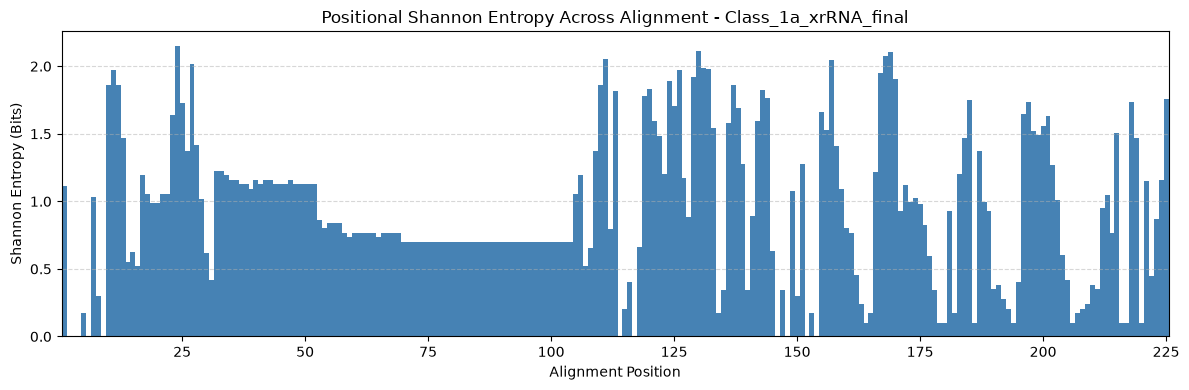

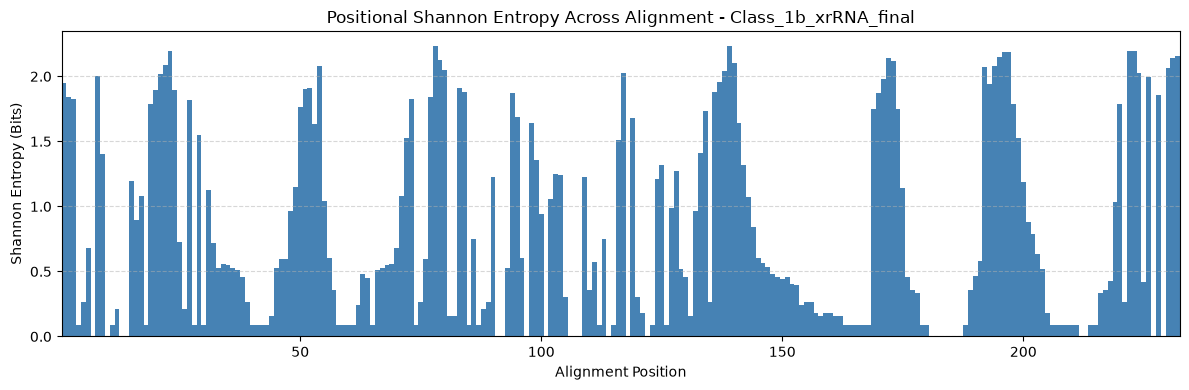

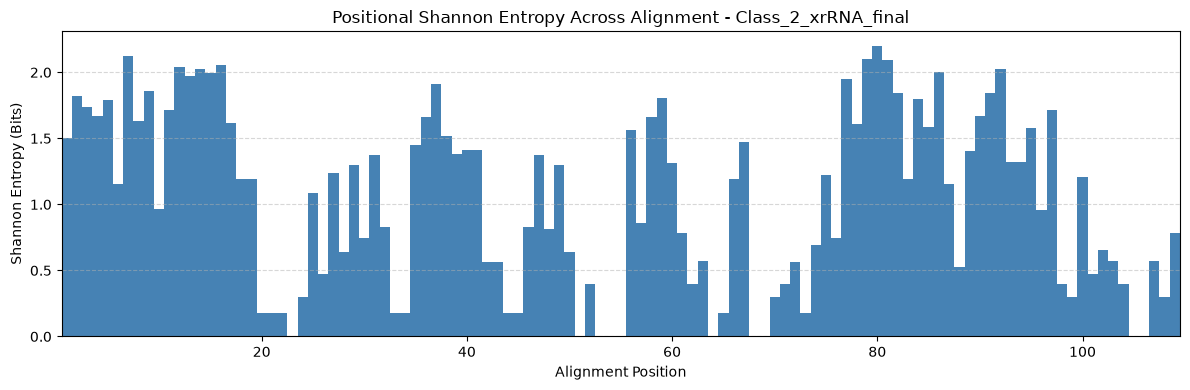

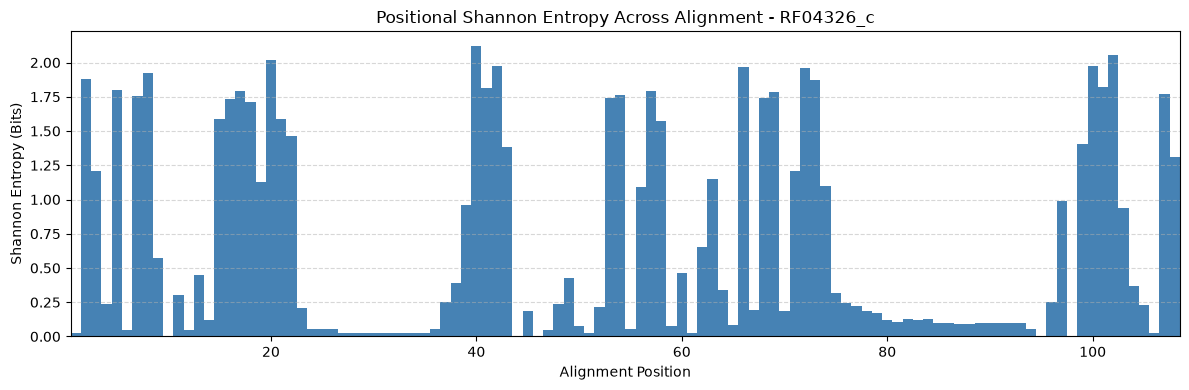

In [60]:
import matplotlib.pyplot as plt

# Loop through each xrRNA class and plot positional entropy
for name, data in entropy_results.items():
    plt.figure(figsize=(12, 4))
    
    # 1-indexed alignment column positions
    positions = range(1, len(data) + 1)
    
    # height of each bar represents the entropy at that column
    plt.bar(
        positions, 
        data, 
        width=1.0, 
        color="steelblue", 
        edgecolor="none"
    )
    
    plt.xlabel("Alignment Position")
    plt.ylabel("Shannon Entropy (Bits)")
    plt.title(f"Positional Shannon Entropy Across Alignment - {name}")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.xlim(0.5, len(data) + 0.5)
    plt.tight_layout()
    plt.show()

Values near or at 0 bits demonstrate that corresponding positions are conserved across aligned sequences of their respective class. This  indicates that these positions account for the essential structures and/or functions of the molecule. The appearance of columns in the region between 1.5 to 2.0 bits demonstrate the presence of nonconserved regions, or regions that are not the same across alignments due to their lack of significance to change xrRNA's structure and/or function.

All classes of xRNA have entropies which vary widely across all positions, with the exception of the region approximately between positions 75-100 in the Class 1a xrRNA, possibly indicating high occupancy of indels ( "." for insertions and "-" for deltions) within the columns of the alignment (instead of bases AUCG). 



# Posterior Probability

Class_1a_xrRNA_final: Processed 75 sequence scores (Mean fit: 0.835)


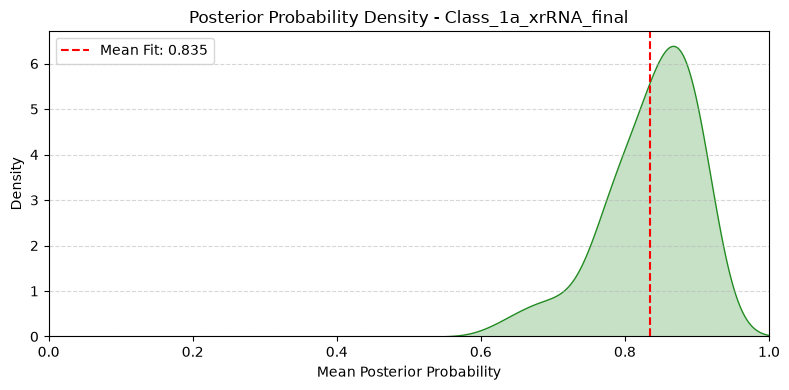

Class_1b_xrRNA_final: Processed 88 sequence scores (Mean fit: 0.811)


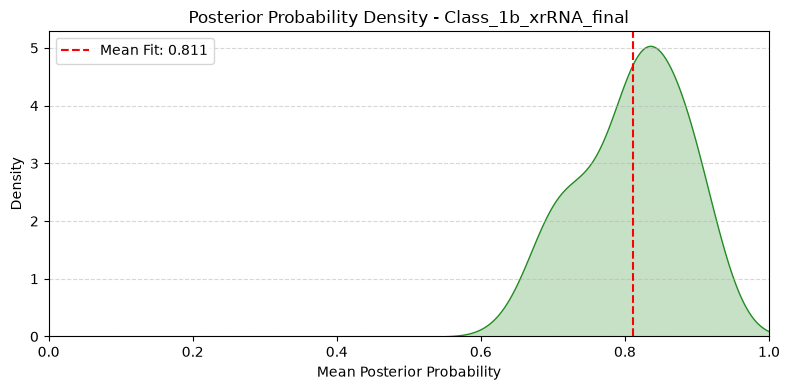

Class_2_xrRNA_final: Processed 38 sequence scores (Mean fit: 0.927)


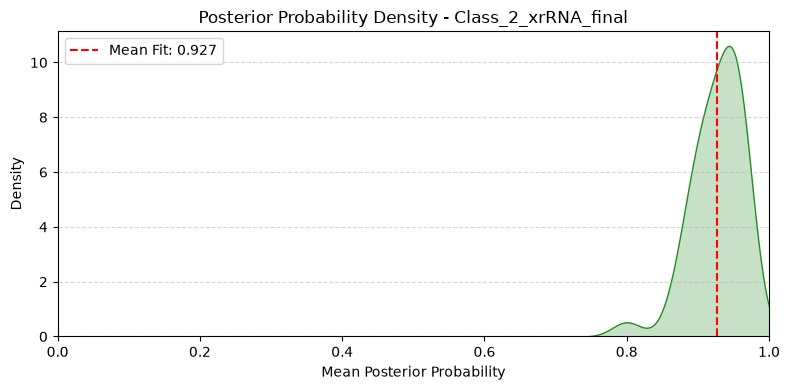

RF04326_c: Processed 354 sequence scores (Mean fit: 0.943)


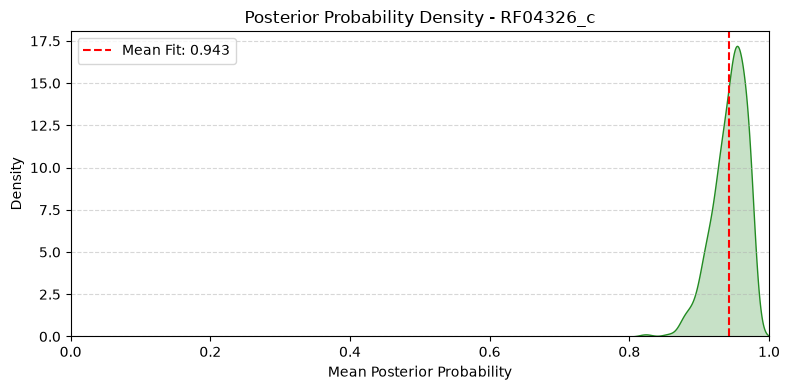

In [61]:
import seaborn as sns

base_dir = os.path.expanduser("~/Desktop/xrRNA")
aligned_dir = os.path.join(base_dir, "cl_check_xrRNA_aligned")

# >95% confidence; high probability | medium probability | low probability and ignore gaps (".")
pp_map = {
    '*': 0.975, '9': 0.90, '8': 0.80, '7': 0.70,
    '6': 0.60,  '5': 0.50, '4': 0.40, '3': 0.30,
    '2': 0.20,  '1': 0.10, '0': 0.05, '.': np.nan
}

# ready to store posterior probabilities
row_pp_results = {}

for file_name in sorted(os.listdir(aligned_dir)):
    if file_name.endswith(".sto"):
        base_name = file_name.replace("_self_aligned.sto", "").replace(".sto", "") # only base names
        file_path = os.path.join(aligned_dir, file_name)
        
        pp_dict = {} # collects posterior probabilities 
        with open(file_path, "r") as f: # read mode
            for line in f:
                if line.startswith("#=GR"): # check for secondary structure in sequence
                    parts = line.split() # split each line of sequence
                    if len(parts) >= 4 and parts[2] == "PP": # each line has at least 4 elements
                        seq_id, pp_str = parts[1], parts[3]
                        pp_dict[seq_id] = pp_dict.get(seq_id, "") + pp_str # append PP strings to handle blocks within .sto

        mean_scores = [] # list for mean confidence score of each sequence
        for seq_id, pp_str in pp_dict.items(): # loop thru each seq and its PP string
            scores = [pp_map[char] for char in pp_str if char in pp_map] # pp_map: character to number
            valid_scores = [s for s in scores if not np.isnan(s)] # filter gaps --> "valid_scores"
            if valid_scores: # there is at least 1 non-gap character
                mean_scores.append(np.mean(valid_scores)) # appended mean of "valid_scores" --> mean scores is pp

        row_pp_results[base_name] = np.array(mean_scores) # store numpy array of mean scores to name of the xrRNA
        
        if mean_scores: # verify that PPs were extracted
            print(f"{base_name}: Processed {len(mean_scores)} sequence scores (Mean fit: {np.mean(mean_scores):.3f})")
            
            # Separate figure for each class
            plt.figure(figsize=(8, 4))
            
            # Separate kernel density estimation (KDE) curve for each class
            sns.kdeplot(
                mean_scores, 
                color="forestgreen", 
                fill=True, 
                bw_adjust=1.2, 
                gridsize=500
            )
            
            plt.axvline(
                x=np.mean(mean_scores), 
                color="red", 
                linestyle="--", 
                label=f"Mean Fit: {np.mean(mean_scores):.3f}"
            )
            
            plt.xlabel("Mean Posterior Probability")
            plt.ylabel("Density")
            plt.title(f"Posterior Probability Density - {base_name}")
            plt.xlim(0, 1.0)
            plt.legend(loc="upper left")
            plt.grid(axis="y", linestyle="--", alpha=0.5)
            plt.tight_layout()
            plt.show()
        else:
            print(f"{base_name}: No #=GR PP posterior probability lines found.")

The above kernel density estimations measure the confidence of the alignment of sequences within a given class against its constructed CM. 
The mean fit line within each plot represents the overall confidence for the alignment.
X-axis: Confidence score
Y-axis: How many of the sequences share a confidence score

Each kernel density plot is relatively narrow with means above 0.8. This means that the sequences and constructed CMs align relatively well, with high confidence. The narrow distribution and lack of multiple peaks indicate low variance and that sequences fit the corresponding model with equal confidence.

The Class 3 xrRNA is the most narrow, with a high peak at approximately 17, indicating high confidence (0.943) of sequence alignment against its CM. 

The Class 1b xrRNA is the most broad, with a peak at 5, indicating lower sequence alignment (0.811) confidence against its corresponding CM compared to the Class 3 xrRNA. 